In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
df = pd.read_csv("../data/raw/data.csv")
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

In [5]:
df.shape

(95662, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

In [7]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [8]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

In [9]:
(df.isnull().sum() / len(df)) * 100

TransactionId           0.0
BatchId                 0.0
AccountId               0.0
SubscriptionId          0.0
CustomerId              0.0
CurrencyCode            0.0
CountryCode             0.0
ProviderId              0.0
ProductId               0.0
ProductCategory         0.0
ChannelId               0.0
Amount                  0.0
Value                   0.0
TransactionStartTime    0.0
PricingStrategy         0.0
FraudResult             0.0
dtype: float64

In [10]:
missing = (df.isnull().sum() / len(df)) * 100
missing = missing[missing > 0].sort_values(ascending=False)
missing

Series([], dtype: float64)

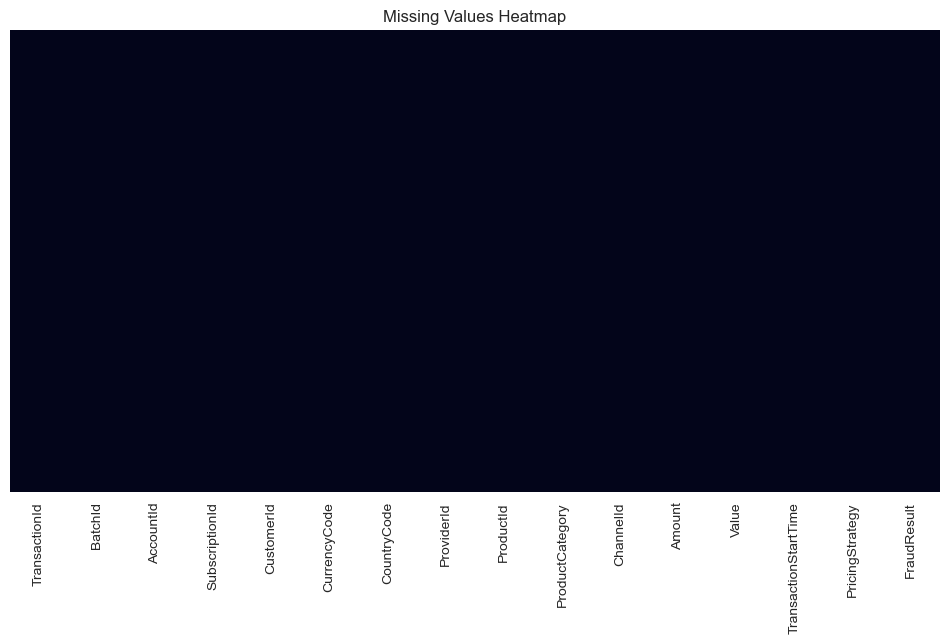

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

In [12]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='object')

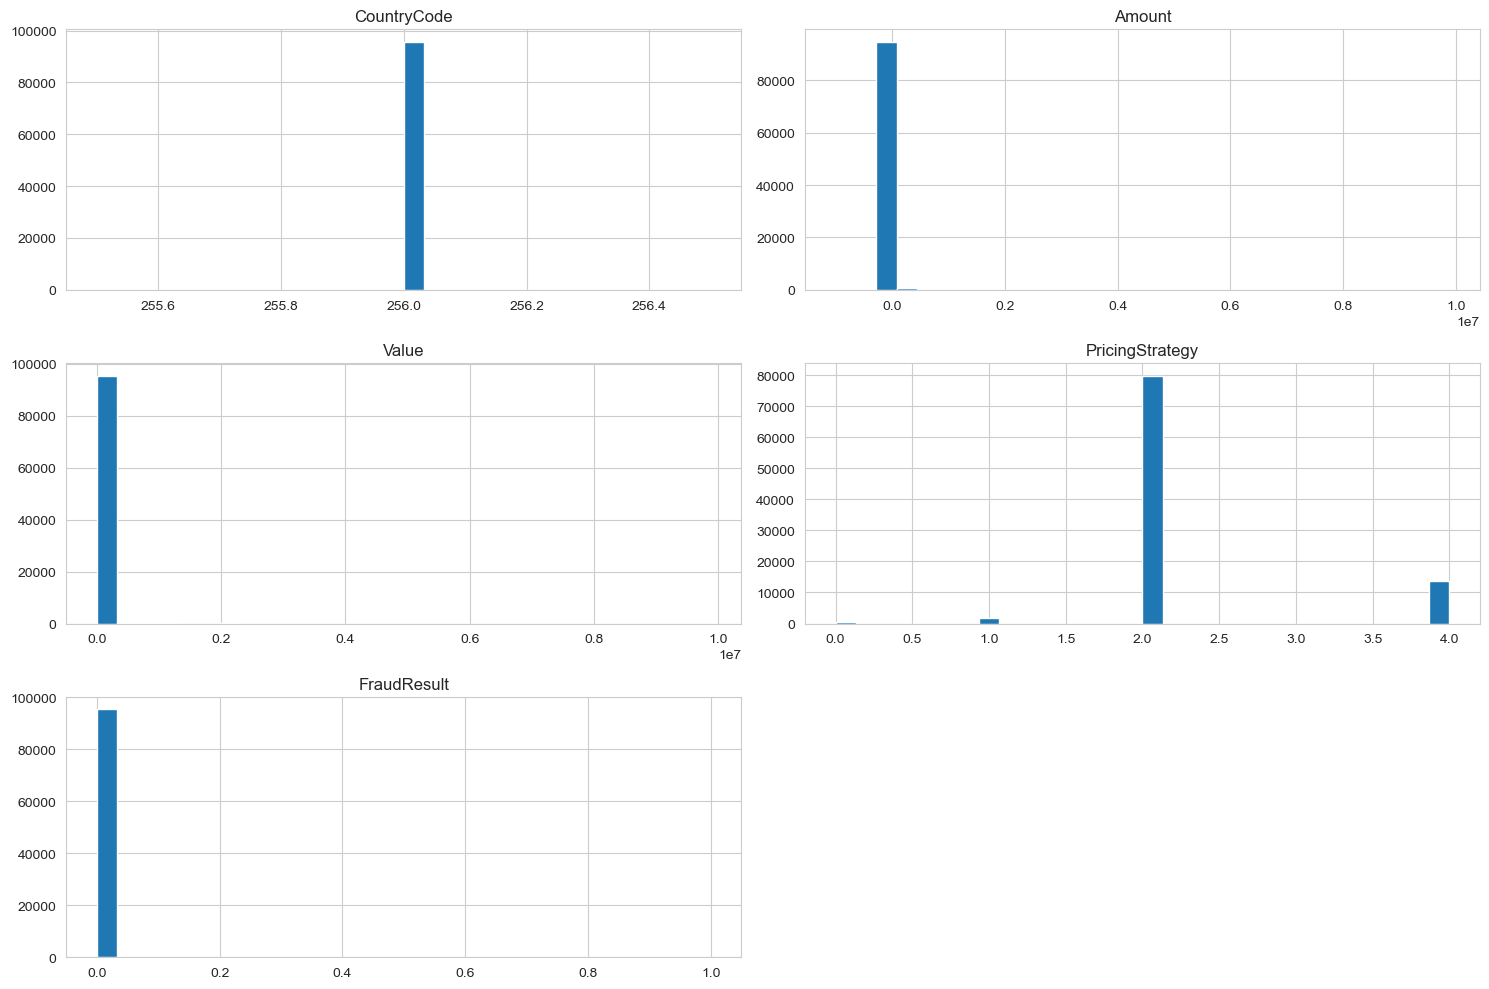

In [13]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

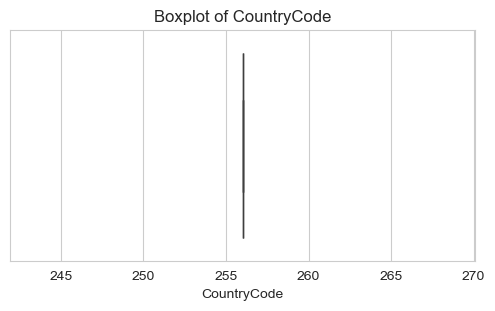

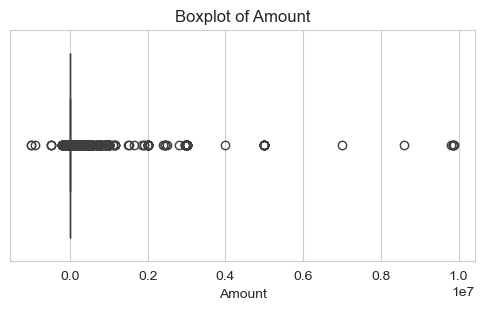

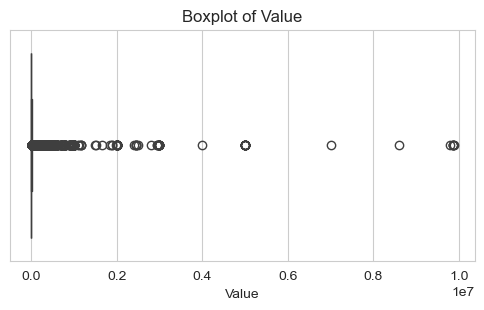

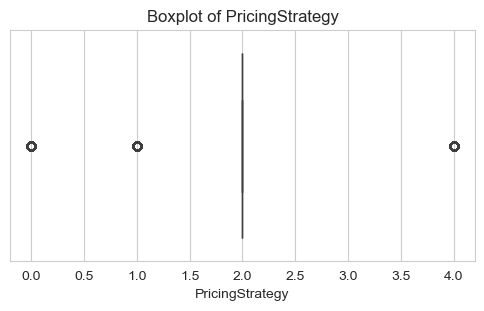

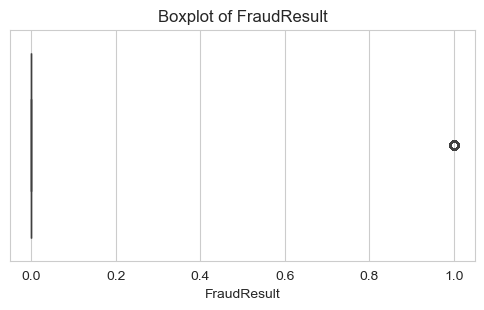

In [14]:
for col in num_cols[:5]:  # first 5 to avoid clutter
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [15]:
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='object')

In [16]:
for col in cat_cols[:5]:
    print("\n", col)
    print(df[col].value_counts().head(10))


 TransactionId
TransactionId
TransactionId_35670     1
TransactionId_76871     1
TransactionId_73770     1
TransactionId_26203     1
TransactionId_380       1
TransactionId_28195     1
TransactionId_23223     1
TransactionId_118063    1
TransactionId_100640    1
TransactionId_51905     1
Name: count, dtype: int64

 BatchId
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
BatchId_88001      9
BatchId_49408      7
BatchId_110084     7
BatchId_34879      6
BatchId_86880      6
Name: count, dtype: int64

 AccountId
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070
AccountId_10        965
AccountId_3595      465
AccountId_751       411
AccountId_2648      359
AccountId_2314      356
Name: count, dtype: int64

 SubscriptionId
SubscriptionId
SubscriptionId_3829    32630
SubscriptionId_4429     4457
SubscriptionId_1372     1105
SubscriptionId_3087    

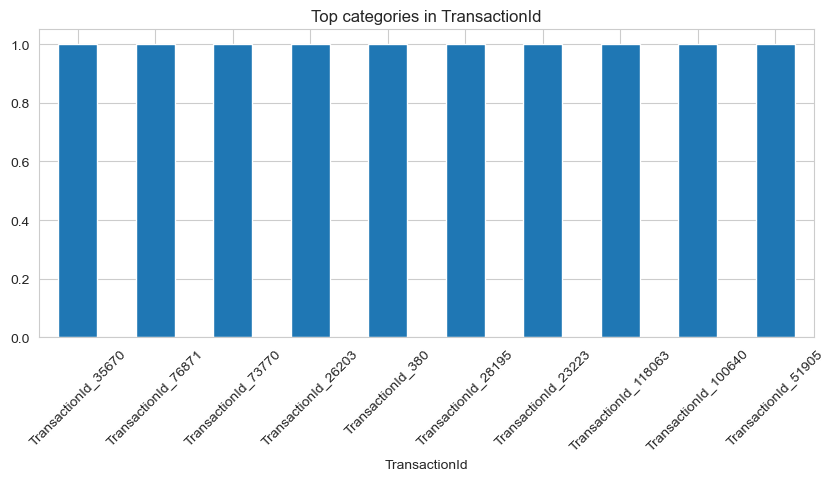

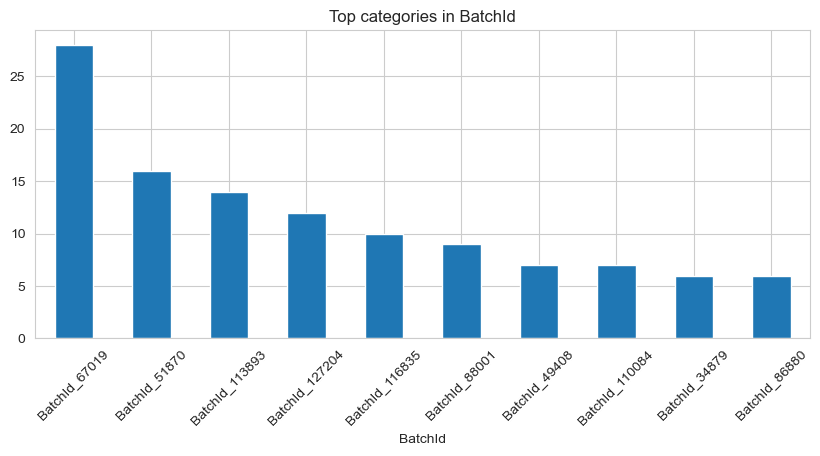

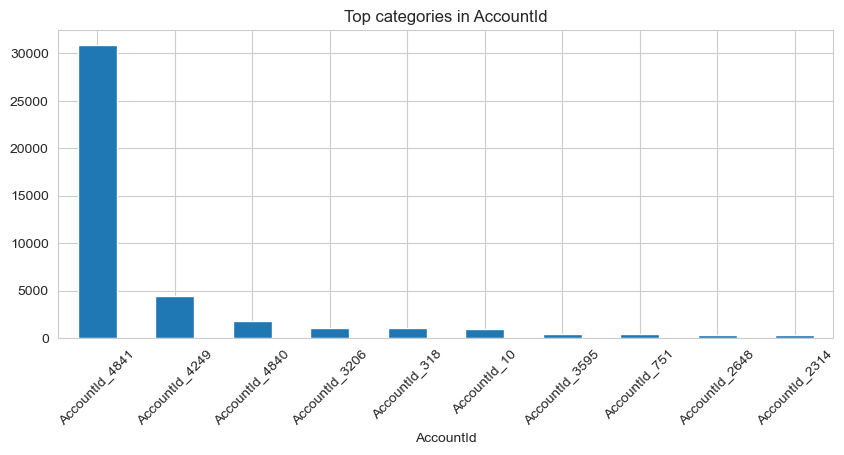

In [17]:
for col in cat_cols[:3]:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top categories in {col}")
    plt.xticks(rotation=45)
    plt.show()

In [18]:
num_df = df.select_dtypes(include=["int64", "float64"])
num_df.head()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
0,256,1000.0,1000,2,0
1,256,-20.0,20,2,0
2,256,500.0,500,2,0
3,256,20000.0,21800,2,0
4,256,-644.0,644,2,0


In [19]:
corr = num_df.corr()
corr

,CountryCode,Amount,Value,PricingStrategy,FraudResult
CountryCode,NaN,NaN,NaN,NaN,NaN
Amount,NaN,1.000000,0.989692,-0.061931,0.557370
Value,NaN,0.989692,1.000000,-0.017020,0.566739
PricingStrategy,NaN,-0.061931,-0.017020,1.000000,-0.033821
FraudResult,NaN,0.557370,0.566739,-0.033821,1.000000


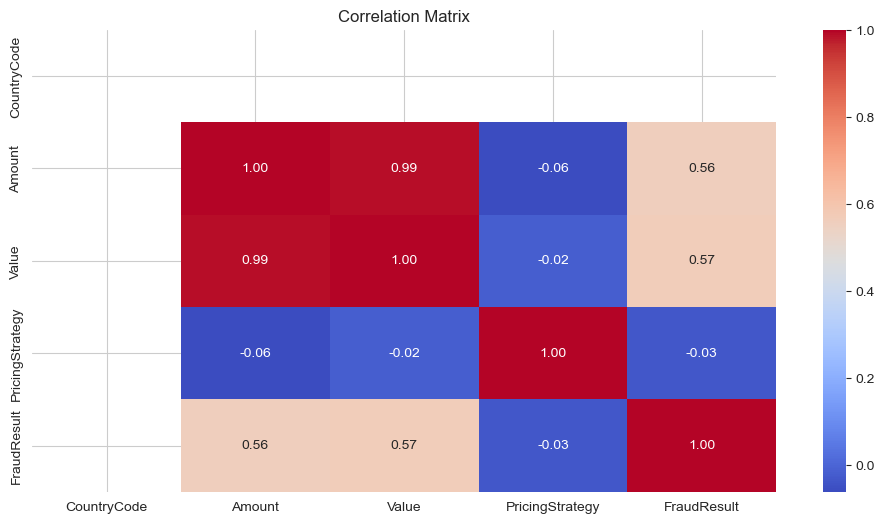

In [20]:
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

. Data Quality
Mention missing values pattern
Whether dataset is clean or noisy
2. Distribution Observations
Skewed numerical features
Presence of outliers
Heavy-tailed transaction behavior
3. Categorical Behavior
Dominant categories in key features
Imbalanced categorical variables
Potential encoding challenges
4. Correlation Findings
Highly correlated features (if any)
Redundant variables
Independence of most predictors
5. Business Insight (VERY IMPORTANT)
Transaction behavior patterns
Possible fraud/risk indicators
Customer segmentation signals

In [26]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin


class CreditFeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # numeric cleaning
        df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

        # time features
        df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])
        df["Transaction_Hour"] = df["TransactionStartTime"].dt.hour
        df["Transaction_Day"] = df["TransactionStartTime"].dt.day
        df["Transaction_Month"] = df["TransactionStartTime"].dt.month
        df["Transaction_Year"] = df["TransactionStartTime"].dt.year

        # aggregation
        agg = df.groupby("CustomerId").agg(
            Total_Transaction_Amount=("Amount", "sum"),
            Avg_Transaction_Amount=("Amount", "mean"),
            Transaction_Count=("TransactionId", "count"),
            Std_Transaction_Amount=("Amount", "std"),
            Avg_Transaction_Hour=("Transaction_Hour", "mean")
        ).reset_index()

        agg["Std_Transaction_Amount"] = agg["Std_Transaction_Amount"].fillna(0)

        return agg

In [27]:
engineer = CreditFeatureEngineer()
output = engineer.transform(df)
output.head()

,CustomerId,Total_Transaction_Amount,Avg_Transaction_Amount,Transaction_Count,Std_Transaction_Amount,Avg_Transaction_Hour
0,CustomerId_1,-10000.0,-10000.000000,1,0.000000,16.000000
1,CustomerId_10,-10000.0,-10000.000000,1,0.000000,16.000000
2,CustomerId_1001,20000.0,4000.000000,5,6558.963333,7.800000
3,CustomerId_1002,4225.0,384.090909,11,560.498966,13.454545
4,CustomerId_1003,20000.0,3333.333333,6,6030.478146,14.333333


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [29]:
num_features = [
    "Total_Transaction_Amount",
    "Avg_Transaction_Amount",
    "Transaction_Count",
    "Std_Transaction_Amount",
    "Avg_Transaction_Hour"
]

In [36]:
cat_features = [
    "Most_Common_Product",
    "Most_Common_Channel",
    "Most_Common_Provider"
]

In [31]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [32]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

In [34]:
full_pipeline = Pipeline(steps=[
    ("feature_engineering", CreditFeatureEngineer()),
    ("preprocessing", preprocessor)
])

In [35]:
model_ready_data = full_pipeline.fit_transform(df)
model_ready_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 22452 stored elements and shape (3742, 3747)>

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [5]:
from src.data_processing import create_rfm_features

rfm = create_rfm_features(df)

rfm.head()

,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1,-10000.0
1,CustomerId_10,84,1,-10000.0
2,CustomerId_1001,90,5,20000.0
3,CustomerId_1002,26,11,4225.0
4,CustomerId_1003,12,6,20000.0


In [6]:
df.shape

(95662, 16)

In [7]:
rfm.shape

(3742, 4)

In [8]:
rfm.head()

,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1,-10000.0
1,CustomerId_10,84,1,-10000.0
2,CustomerId_1001,90,5,20000.0
3,CustomerId_1002,26,11,4225.0
4,CustomerId_1003,12,6,20000.0
